In [1]:
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, 
                                     BatchNormalization, ReLU, GlobalAveragePooling1D, Reshape, multiply, add)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Define dataset directories
DATA_DIR_REAL = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/real_ecgs"
DATA_DIR_FAKE = "C:/Users/M2-Winterfell/Downloads/combined_fake_ecgs"

# Additional directories for real data (each will provide 50 random files)
ADDITIONAL_REAL_DIRS = [
    "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/cnn_fake",
    "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/pulse2pulse_fake",
    "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/timegan_fake",
    "C:/Users/M2-Winterfell/Downloads/pulse2pulse_150k/from_006_chkp_2500_150k"
]

# Updated function to load and extract Lead I from a single .asc file
def load_lead_I_from_asc(file_path):
    try:
        # Load the .asc file (assuming it's space or tab-delimited)
        ecg_data = np.loadtxt(file_path)
        # If the file has multiple columns, extract the first column; otherwise, use the data as is.
        if ecg_data.ndim > 1 and ecg_data.shape[1] > 1:
            lead_I = ecg_data[:, 0]
        else:
            lead_I = ecg_data
        return lead_I
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

# Function to load a specified number of sequentially named .asc files from a directory.
def load_sequential_lead_I_from_directory(data_dir, n):
    all_lead_I = []
    i = 0
    with tqdm(total=n, desc=f"Loading Lead I from {os.path.basename(data_dir)}", unit='file') as pbar:
        while len(all_lead_I) < n:
            file_name = f"{i}.asc"
            file_path = os.path.join(data_dir, file_name)
            if os.path.exists(file_path):
                lead_I = load_lead_I_from_asc(file_path)
                if lead_I is not None:
                    all_lead_I.append(lead_I)
                    pbar.update(1)
            i += 1
    return np.array(all_lead_I)

# Function to load a specified number of random .asc files from a directory.
def load_random_lead_I_from_directory(data_dir, n):
    # List all .asc files in the directory
    all_files = [f for f in os.listdir(data_dir) if f.endswith('.asc')]
    if len(all_files) < n:
        print(f"Warning: Requested {n} files but only found {len(all_files)} in {data_dir}.")
        selected_files = all_files
    else:
        selected_files = random.sample(all_files, n)
    
    lead_I_list = []
    for file_name in tqdm(selected_files, desc=f"Randomly loading Lead I from {os.path.basename(data_dir)}", unit='file'):
        file_path = os.path.join(data_dir, file_name)
        lead_I = load_lead_I_from_asc(file_path)
        if lead_I is not None:
            lead_I_list.append(lead_I)
    return np.array(lead_I_list)

# --------------------------
# Loading Real Data (Total = 2000 files)
# --------------------------
# 1. Load 1800 sequential files from the real_ecgs folder.
lead_I_real_primary = load_sequential_lead_I_from_directory(DATA_DIR_REAL, 1800)

# 2. Load 200 additional files by randomly selecting 50 files from each of the 4 additional directories.
lead_I_real_additional = []
for additional_dir in ADDITIONAL_REAL_DIRS:
    data = load_random_lead_I_from_directory(additional_dir, 50)
    lead_I_real_additional.append(data)

# Concatenate additional real data from all extra directories
lead_I_real_additional = np.concatenate(lead_I_real_additional, axis=0)

# Combine the primary and additional real data
lead_I_real = np.concatenate([lead_I_real_primary, lead_I_real_additional], axis=0)

# --------------------------
# Loading Fake Data (2000 sequential files)
# --------------------------
lead_I_fake = load_sequential_lead_I_from_directory(DATA_DIR_FAKE, 2000)

# Check if data was loaded successfully
if lead_I_fake.size > 0 and lead_I_real.size > 0:
    print(f"Total Lead I records loaded from real data: {lead_I_real.shape[0]}")
    print(f"Total Lead I records loaded from fake data: {lead_I_fake.shape[0]}")
else:
    print("No data was loaded.")


Randomly loading Lead I from timegan_fake: 100%|██████████| 50/50 [00:00<00:00, 89.89file/s]
Randomly loading Lead I from from_006_chkp_2500_150k: 100%|██████████| 50/50 [00:00<00:00, 50.80file/s]
Loading Lead I from combined_fake_ecgs: 100%|██████████| 2000/2000 [00:31<00:00, 63.74file/s]


Total Lead I records loaded from real data: 2000
Total Lead I records loaded from fake data: 2000


In [2]:
def min_max_normalize(data):
    min_val = np.min(data)
    max_val = np.max(data)
    return 2 * (data - min_val) / (max_val - min_val) - 1

lead_I_real = np.array([min_max_normalize(ecg) for ecg in lead_I_real])
lead_I_fake = np.array([min_max_normalize(ecg) for ecg in lead_I_fake])

# Combine data and labels
X = np.concatenate((lead_I_fake, lead_I_real), axis=0)
y = np.concatenate((np.zeros(lead_I_fake.shape[0]), np.ones(lead_I_real.shape[0])), axis=0)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Reshape data to (samples, time_steps, 1)
INPUT_SHAPE = (X_train.shape[1], 1)
X_train = X_train.reshape(-1, X_train.shape[1], 1)
X_test = X_test.reshape(-1, X_test.shape[1], 1)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (3200, 5000, 1)
X_test shape: (800, 5000, 1)


In [3]:

# ---- ResNet-Attention Model Definition ----

def squeeze_excite_block(input_tensor, ratio=16):
    """Squeeze-and-Excitation block for channel-wise attention."""
    filters = input_tensor.shape[-1]
    se = GlobalAveragePooling1D()(input_tensor)
    se = Reshape((1, filters))(se)
    se = Dense(filters // ratio, activation='relu',
               kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid',
               kernel_initializer='he_normal', use_bias=False)(se)
    x = multiply([input_tensor, se])
    return x

def res_block(x, filters, kernel_size=3, stride=1):
    """Residual block with squeeze-and-excitation attention."""
    shortcut = x
    # First convolutional layer
    x = Conv1D(filters, kernel_size, strides=stride, padding='same', 
               kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    # Second convolutional layer
    x = Conv1D(filters, kernel_size, strides=1, padding='same', 
               kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    # Attention module
    x = squeeze_excite_block(x)
    # Adjust shortcut dimensions if necessary
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same', 
                          kernel_initializer='he_normal')(shortcut)
        shortcut = BatchNormalization()(shortcut)
    # Add shortcut connection and apply activation
    x = add([x, shortcut])
    x = ReLU()(x)
    return x

# Build the model using the functional API
inputs = Input(shape=INPUT_SHAPE)
# Initial convolution layer
x = Conv1D(32, kernel_size=3, padding='same', kernel_initializer='he_normal')(inputs)
x = BatchNormalization()(x)
x = ReLU()(x)

# First Residual Block (32 filters)
x = res_block(x, 32, kernel_size=3, stride=1)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.25)(x)

# Second Residual Block (64 filters)
x = res_block(x, 64, kernel_size=3, stride=1)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.25)(x)

# Third Residual Block (128 filters)
x = res_block(x, 128, kernel_size=3, stride=1)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.25)(x)

x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.25)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model
optimizer = Adam(learning_rate=0.005)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# EarlyStopping callback to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1)

# Train the model
batch_size = 32
history = model.fit(X_train, y_train, 
                    epochs=50, 
                    batch_size=batch_size,
                    validation_data=(X_test, y_test), 
                    callbacks=[early_stop])

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Save the model
# model.save("my_ecg_model.h5")
# print("Model saved successfully.")

Epoch 1/50
100/100 [==============================] - 124s 1s/step - loss: 7.0582 - accuracy: 0.6541 - val_loss: 0.6203 - val_accuracy: 0.7125
Epoch 2/50
100/100 [==============================] - 120s 1s/step - loss: 0.5408 - accuracy: 0.7344 - val_loss: 0.6572 - val_accuracy: 0.5375
Epoch 3/50
100/100 [==============================] - 120s 1s/step - loss: 0.4756 - accuracy: 0.7791 - val_loss: 0.6153 - val_accuracy: 0.6037
Epoch 4/50
100/100 [==============================] - 127s 1s/step - loss: 0.4414 - accuracy: 0.8125 - val_loss: 0.6595 - val_accuracy: 0.5863
Epoch 5/50
100/100 [==============================] - 111s 1s/step - loss: 0.3612 - accuracy: 0.8569 - val_loss: 0.4897 - val_accuracy: 0.7663
Epoch 6/50
100/100 [==============================] - 106s 1s/step - loss: 0.2840 - accuracy: 0.8981 - val_loss: 0.4043 - val_accuracy: 0.8313
Epoch 7/50
100/100 [==============================] - 119s 1s/step - loss: 0.2361 - accuracy: 0.9197 - val_loss: 0.2894 - val_accuracy: 0.9050

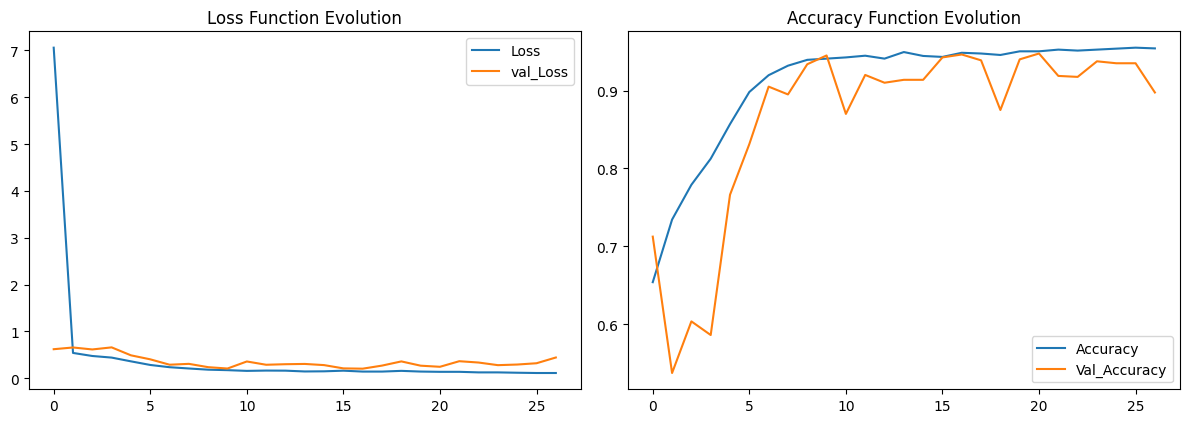

In [4]:
# Plotting Training History
plt.figure(figsize=(12, 16))

# Loss plot
plt.subplot(4, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='val_Loss')
plt.title('Loss Function Evolution')
plt.legend()

# Accuracy plot
plt.subplot(4, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val_Accuracy')
plt.title('Accuracy Function Evolution')
plt.legend()

plt.tight_layout()
plt.show()

25/25 [==============================] - 5s 187ms/step - loss: 0.4432 - accuracy: 0.8975
Test Accuracy: 89.75%
25/25 [==============================] - 6s 201ms/step


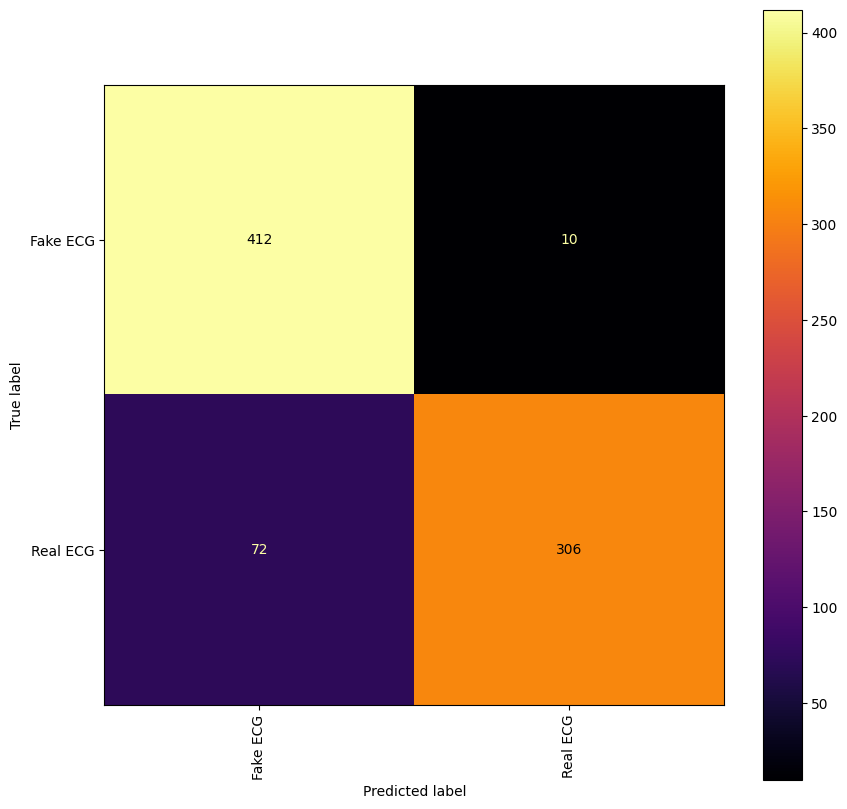

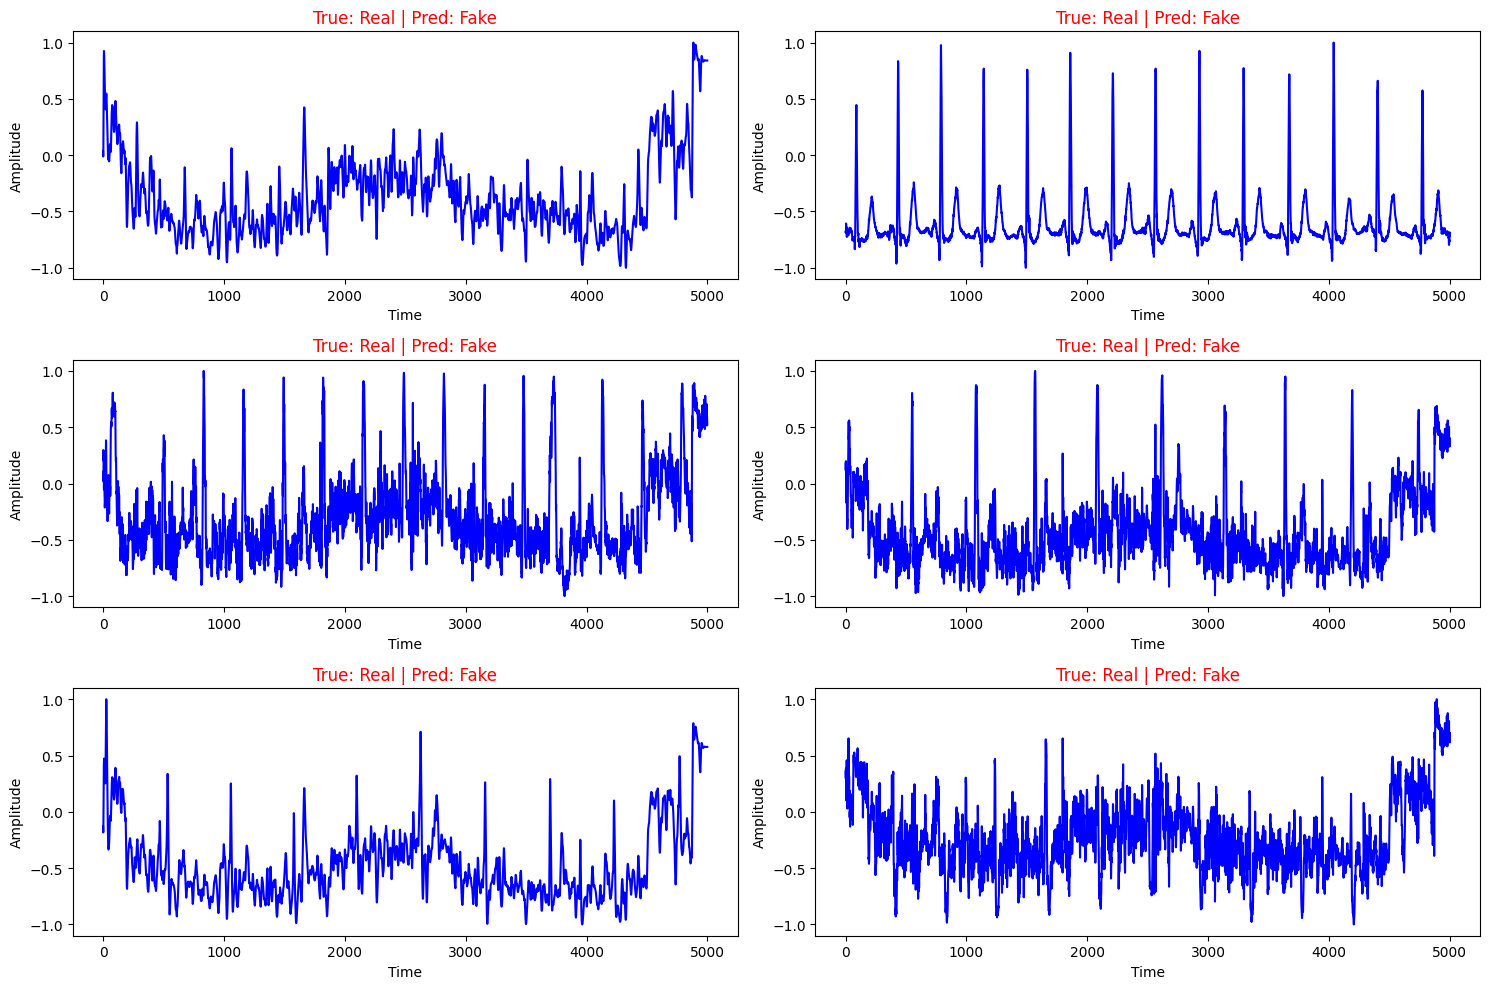

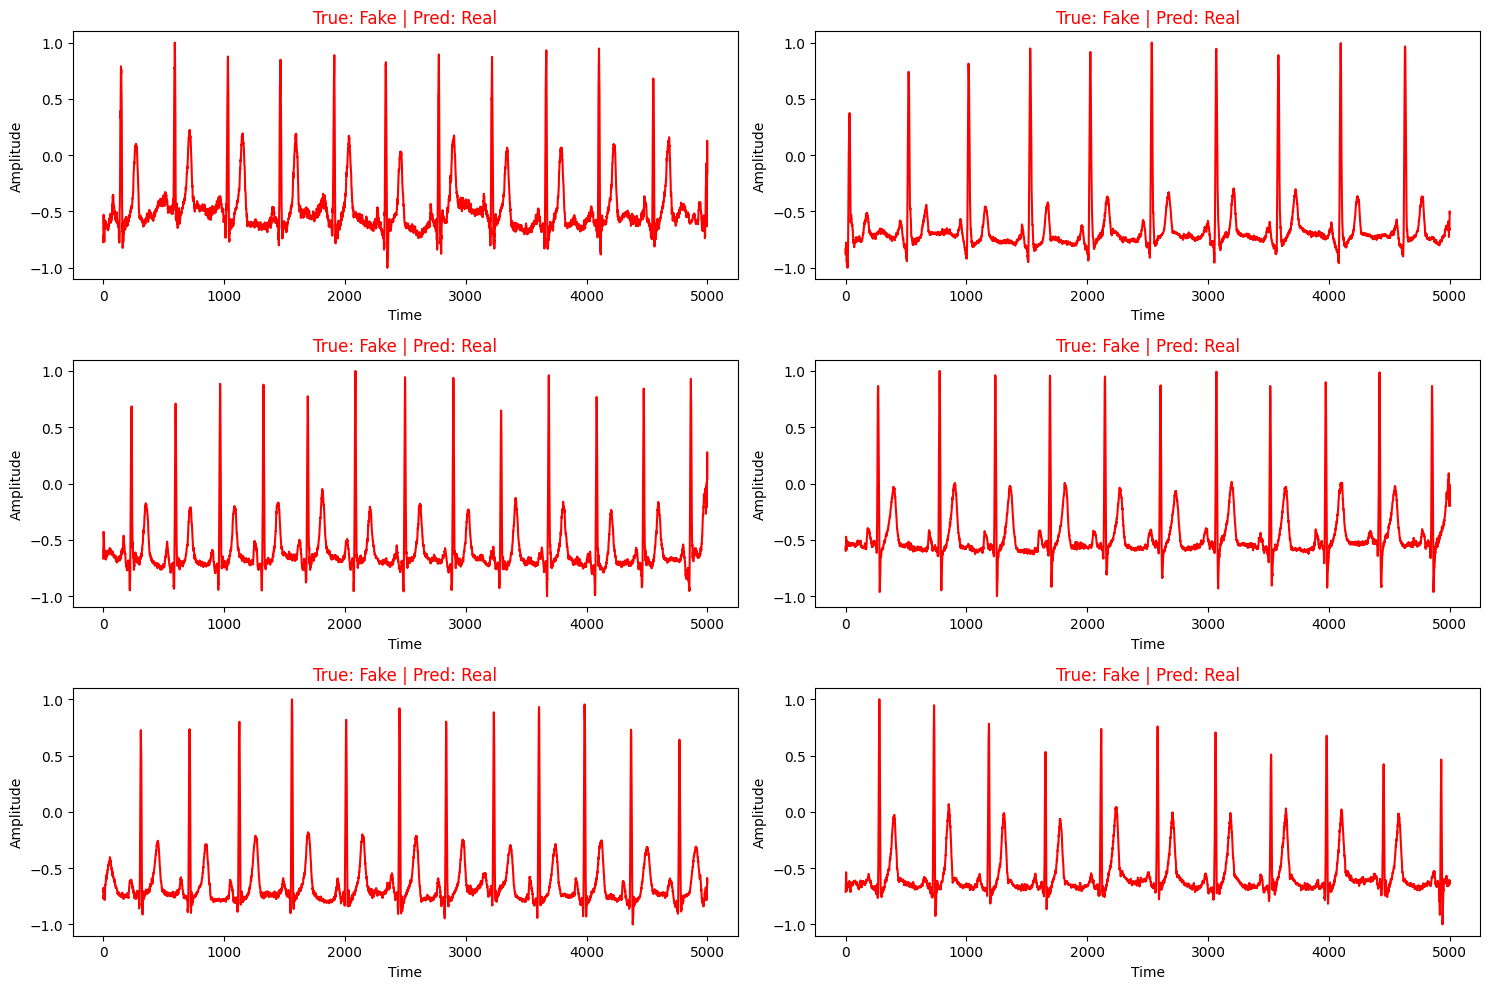

In [5]:
# Model Evaluation
evaluation = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {evaluation[1] * 100:.2f}%')

# Predict on test set
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype("int32").flatten()  # Convert probabilities to binary labels (0 or 1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake ECG", "Real ECG"])
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(xticks_rotation='vertical', ax=ax, cmap='inferno')
plt.show()

# -----------------------------------------------------------
# Plot 6 samples that are False Negatives (True: Real, Predicted: Fake)
# -----------------------------------------------------------
false_negatives = [i for i in range(len(X_test)) if (y_test[i] == 1 and y_pred[i] == 0)]
num_fn = min(6, len(false_negatives))

if num_fn > 0:
    plt.figure(figsize=(15, 10))
    for j in range(num_fn):
        idx = false_negatives[j]
        plt.subplot(3, 2, j + 1)
        # True label is Real so plot in blue, but prediction is Fake
        plt.plot(X_test[idx].squeeze(), color='blue')
        plt.title("True: Real | Pred: Fake", color='red')
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()
else:
    print("No false negatives found.")

# -----------------------------------------------------------
# Plot 6 samples that are False Positives (True: Fake, Predicted: Real)
# -----------------------------------------------------------
false_positives = [i for i in range(len(X_test)) if (y_test[i] == 0 and y_pred[i] == 1)]
num_fp = min(6, len(false_positives))

if num_fp > 0:
    plt.figure(figsize=(15, 10))
    for j in range(num_fp):
        idx = false_positives[j]
        plt.subplot(3, 2, j + 1)
        # True label is Fake so plot in red, but prediction is Real
        plt.plot(X_test[idx].squeeze(), color='red')
        plt.title("True: Fake | Pred: Real", color='red')
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()
else:
    print("No false positives found.")